Device      : cuda
DIR_128     : D:\22\AA\evaluation\supcon_c7_l02_t005_context7_artifact-aware_ContextCnnTransformerF
DIR_256     : D:\22\AA\evaluation\supcon_c7_dmodel_256_artifact-aware
Output      : D:\22\AA\evaluation\ensemble_cross_model_128_256
Test subjects: 20

Loading test dataset...
Test samples: 19,763

Loading d128 models (d_model=128) from:
  D:\22\AA\evaluation\supcon_c7_l02_t005_context7_artifact-aware_ContextCnnTransformerF
  ✓ Loaded: best_seed42.pt
  ✓ Loaded: best_seed123.pt
  ✓ Loaded: best_seed256.pt
  ✓ Loaded: best_seed789.pt
  ✓ Loaded: best_seed999.pt

Loading d256 models (d_model=256) from:
  D:\22\AA\evaluation\supcon_c7_dmodel_256_artifact-aware
  ✓ Loaded: best_seed42.pt
  ✓ Loaded: best_seed123.pt
  ✓ Loaded: best_seed256.pt
  ✓ Loaded: best_seed789.pt
  ✓ Loaded: best_seed999.pt

Total ensemble size: 10 models
  d_model=128 : 5 models
  d_model=256 : 5 models

Running inference — d_model=128 models:
  d128_seed42 done
  d128_seed123 done
  d128_seed256 d

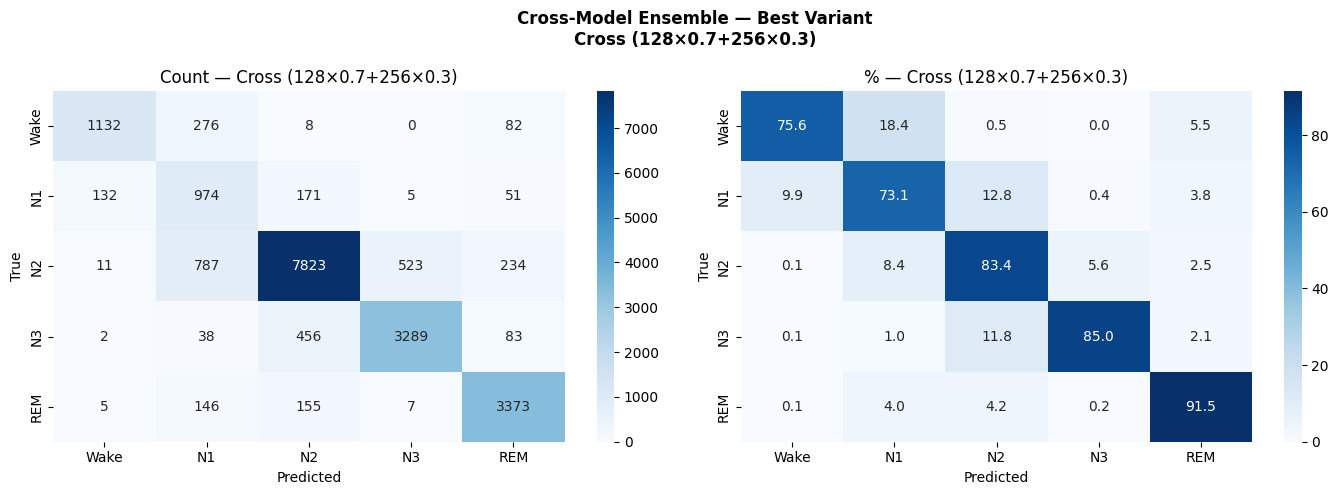

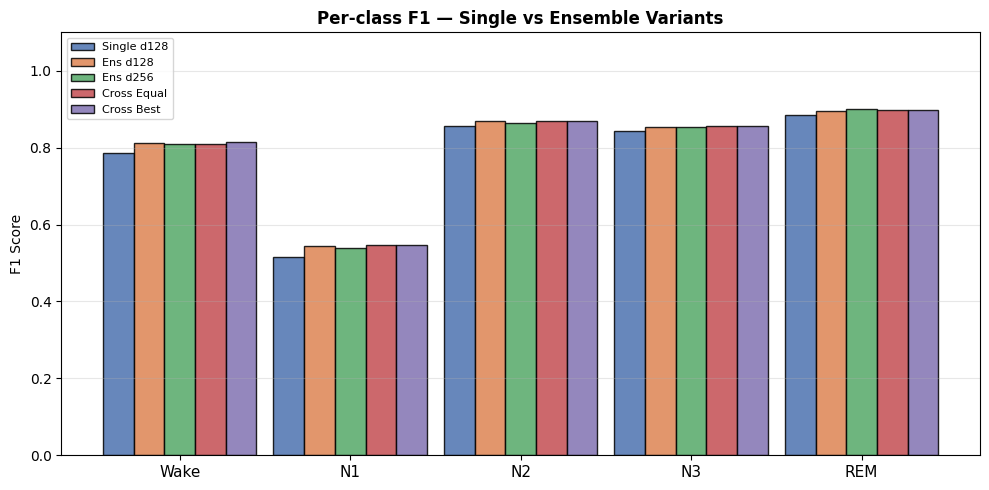


Outputs saved: D:\22\AA\evaluation\ensemble_cross_model_128_256
Done!


In [1]:
# ============================================================
# Cross-Model Heterogeneous Ensemble
# d_model=128 (5 seeds) + d_model=256 (5 seeds) = 10 models
#
# References:
#   - SOMNUS (Rossi et al., arXiv 2025): soft-voting across
#     different architectures consistently exceeds single model
#   - Fernandez-Blanco et al. (Multimed Tools Appl, 2025):
#     heterogeneous CNN ensemble for sleep staging
#   - Salfi et al. (bioRxiv, 2025): Zmax wearable ensemble
#
# কোনো training নেই — শুধু inference।
# ============================================================

import os
import math
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from sklearn.metrics import (
    accuracy_score, f1_score,
    cohen_kappa_score, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# ============================================================
# PATHS
# ============================================================
SAVE_PATH     = r"D:\22\AA\preprocess\preprocessed_FFinal"
ARTIFACT_PATH = r"D:\22\thesis 3233\Wearanize+_PlugNPlay_v1.0\Wearanize+_PlugNPlay_v1.0\derivatives\eegfloss-v1.0"

# d_model=128 checkpoints (তোমার best model)
DIR_128 = r"D:\22\AA\evaluation\supcon_c7_l02_t005_context7_artifact-aware_ContextCnnTransformerF"

# d_model=256 checkpoints
DIR_256 = r"D:\22\AA\evaluation\supcon_c7_dmodel_256_artifact-aware"

EVAL_PATH = r"D:\22\AA\evaluation\ensemble_cross_model_128_256"
os.makedirs(EVAL_PATH, exist_ok=True)

LABEL_NAMES = ["Wake", "N1", "N2", "N3", "REM"]
CONTEXT     = 7
WINDOW      = 2 * CONTEXT + 1
BATCH_SIZE  = 64
SEEDS       = [42, 123, 256, 789, 999]

ARTIFACT_WEIGHT_MAP = {0: 1.0, 1: 0.0, 2: 0.4, 3: 0.2, 4: 0.1}
TARGET_CHANNELS     = ["PSG_F3:A2", "PSG_C3:A2"]
FALLBACK_CHANNELS   = ["PSG_F3", "PSG_C3", "Zmax_EEGL", "Zmax_EEGR"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device      : {device}")
print(f"DIR_128     : {DIR_128}")
print(f"DIR_256     : {DIR_256}")
print(f"Output      : {EVAL_PATH}")


# ============================================================
# ARTIFACT WEIGHT LOADER
# ============================================================
def load_artifact_weights(subject_id, artifact_path, epoch_duration=30):
    tsv_path = os.path.join(
        artifact_path, subject_id, "eeg",
        f"{subject_id}_task-sleep_proc-artifacts.tsv"
    )
    if not os.path.exists(tsv_path):
        return None
    try:
        df = pd.read_csv(tsv_path, sep='\t')
    except Exception:
        return None

    available = [ch for ch in TARGET_CHANNELS if ch in df.columns]
    if not available:
        available = [ch for ch in FALLBACK_CHANNELS if ch in df.columns]
    if not available:
        return None

    df['worst_score'] = df[available].max(axis=1).astype(int)
    df['sleep_epoch'] = ((df['offset'] - 1e-6) // epoch_duration).astype(int)
    epoch_scores = df.groupby('sleep_epoch')['worst_score'].max()

    n_ep    = int(epoch_scores.index.max()) + 1
    weights = np.ones(n_ep, dtype=np.float32)
    for ep_idx, score in epoch_scores.items():
        weights[int(ep_idx)] = ARTIFACT_WEIGHT_MAP.get(int(score), 1.0)
    return weights


# ============================================================
# FIXED TEST SPLIT
# ============================================================
_test_path = os.path.join(SAVE_PATH, "_test_subs.npy")
TEST_SUBS  = np.load(_test_path, allow_pickle=True).tolist()
print(f"Test subjects: {len(TEST_SUBS)}")


# ============================================================
# DATASET
# ============================================================
class ArtifactAwareDataset(Dataset):
    def __init__(self, subject_list, data_path,
                 artifact_path, context=CONTEXT):
        self.context = context
        self.data    = []
        self.index   = []

        for sub in subject_list:
            fp = os.path.join(data_path, f"{sub}.npz")
            if not os.path.exists(fp):
                continue
            with np.load(fp) as d:
                eeg    = d['eeg'][:, [0, 1], :]
                eog    = d['eog'][:, [0],    :]
                signal = np.concatenate([eeg, eog], axis=1).astype(np.float32)
                labels = d['labels'].copy()

            n     = len(labels)
            art_w = load_artifact_weights(sub, artifact_path)
            if art_w is None:
                art_w = np.ones(n, dtype=np.float32)
            else:
                if len(art_w) >= n:
                    art_w = art_w[:n]
                else:
                    art_w = np.concatenate([art_w, np.ones(n - len(art_w), dtype=np.float32)])

            sub_idx = len(self.data)
            self.data.append((signal, labels))
            for i in range(n):
                self.index.append((sub_idx, i, n, float(art_w[i])))

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        sub_idx, center_i, n, weight = self.index[idx]
        signal, labels = self.data[sub_idx]
        window_epochs  = []
        for offset in range(-self.context, self.context + 1):
            ei = max(0, min(n - 1, center_i + offset))
            window_epochs.append(signal[ei])
        x = np.stack(window_epochs, axis=0)
        y = int(labels[center_i])
        return (
            torch.FloatTensor(x),
            torch.tensor(y, dtype=torch.long),
            torch.tensor(weight, dtype=torch.float32)
        )


print("\nLoading test dataset...")
test_ds     = ArtifactAwareDataset(TEST_SUBS, SAVE_PATH, ARTIFACT_PATH)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f"Test samples: {len(test_ds):,}")


# ============================================================
# POSITIONAL ENCODING
# ============================================================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1), :])


# ============================================================
# MODEL — supports any d_model
# ============================================================
class ContextCNNTransformerSupCon(nn.Module):
    def __init__(
        self, in_ch=3, d_model=128, nhead=8,
        num_layers=3, dim_ff=256, dropout=0.4,
        n_classes=5, context=CONTEXT, proj_dim=64
    ):
        super().__init__()
        self.context = context
        self.d_model  = d_model

        self.epoch_cnn = nn.Sequential(
            nn.Conv1d(in_ch, 32, kernel_size=50, stride=6, padding=25),
            nn.BatchNorm1d(32), nn.GELU(),
            nn.MaxPool1d(4, 4),
            nn.Conv1d(32, 64, kernel_size=8, padding=4),
            nn.BatchNorm1d(64), nn.GELU(),
            nn.Conv1d(64, d_model, kernel_size=8, padding=4),
            nn.BatchNorm1d(d_model), nn.GELU(),
            nn.MaxPool1d(2, 2),
            nn.Dropout(dropout),
        )
        with torch.no_grad():
            intra_seq = self.epoch_cnn(torch.zeros(1, in_ch, 3000)).shape[2]

        self.intra_pos = PositionalEncoding(d_model, max_len=intra_seq + 10, dropout=dropout)
        self.intra_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=d_model, nhead=nhead,
                dim_feedforward=dim_ff, dropout=dropout,
                activation='gelu', batch_first=True, norm_first=True
            ), num_layers=1
        )
        self.inter_pos = PositionalEncoding(d_model, max_len=WINDOW + 2, dropout=dropout)
        self.inter_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=d_model, nhead=nhead,
                dim_feedforward=dim_ff, dropout=dropout,
                activation='gelu', batch_first=True, norm_first=True
            ), num_layers=num_layers
        )
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 64), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes),
        )
        self.projector = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model), nn.GELU(),
            nn.Linear(d_model, proj_dim),
        )

    def forward(self, x):
        B, W, C, T = x.shape
        feat = self.epoch_cnn(x.view(B * W, C, T)).permute(0, 2, 1)
        feat = self.intra_transformer(
            self.intra_pos(feat)
        ).mean(dim=1).view(B, W, self.d_model)
        feat = self.inter_transformer(self.inter_pos(feat))
        center = feat[:, self.context, :]
        logits = self.classifier(center)
        proj   = F.normalize(self.projector(center), dim=1)
        return logits, proj


# ============================================================
# LOAD ALL 10 MODELS
# ============================================================
def load_models_from_dir(checkpoint_dir, d_model, dim_ff, proj_dim, label):
    models = []
    print(f"\nLoading {label} models (d_model={d_model}) from:")
    print(f"  {checkpoint_dir}")
    for seed in SEEDS:
        ckpt = os.path.join(checkpoint_dir, f"best_seed{seed}.pt")
        if not os.path.exists(ckpt):
            print(f"  ✗ NOT FOUND: best_seed{seed}.pt")
            continue
        m = ContextCNNTransformerSupCon(
            in_ch=3, d_model=d_model,
            dim_ff=dim_ff, proj_dim=proj_dim
        ).to(device)
        m.load_state_dict(torch.load(ckpt, map_location=device))
        m.eval()
        models.append((f"{label}_seed{seed}", m))
        print(f"  ✓ Loaded: best_seed{seed}.pt")
    return models

models_128 = load_models_from_dir(DIR_128, d_model=128, dim_ff=256, proj_dim=64,  label="d128")
models_256 = load_models_from_dir(DIR_256, d_model=256, dim_ff=512, proj_dim=64,  label="d256")

all_models = models_128 + models_256
print(f"\nTotal ensemble size: {len(all_models)} models")
print(f"  d_model=128 : {len(models_128)} models")
print(f"  d_model=256 : {len(models_256)} models")


# ============================================================
# COLLECT LABELS & WEIGHTS
# ============================================================
all_labels  = []
all_weights = []
with torch.no_grad():
    for x, y, w in test_loader:
        all_labels.extend(y.numpy())
        all_weights.extend(w.numpy())
all_labels  = np.array(all_labels)
all_weights = np.array(all_weights)


# ============================================================
# GET PROBABILITIES FROM ALL MODELS
# ============================================================
def get_probs(model_list, loader):
    probs_list = []
    for name, model in model_list:
        model_probs = []
        with torch.no_grad():
            for x, y, w in loader:
                logits, _ = model(x.to(device))
                probs = F.softmax(logits, dim=1).cpu().numpy()
                model_probs.append(probs)
        model_probs = np.concatenate(model_probs, axis=0)
        probs_list.append(model_probs)
        print(f"  {name} done")
    return np.stack(probs_list, axis=0)   # (N_models, N, 5)


print("\nRunning inference — d_model=128 models:")
probs_128 = get_probs(models_128, test_loader)

print("\nRunning inference — d_model=256 models:")
probs_256 = get_probs(models_256, test_loader)

# All 10 models combined
probs_all = np.concatenate([probs_128, probs_256], axis=0)  # (10, N, 5)


# ============================================================
# HELPER — compute metrics
# ============================================================
def compute_metrics(preds, labels, weights):
    acc     = accuracy_score(labels, preds)
    f1      = f1_score(labels, preds, average='macro', zero_division=0)
    kappa   = cohen_kappa_score(labels, preds)
    per_cls = f1_score(labels, preds, average=None, zero_division=0)
    clean_m = weights == 1.0
    noisy_m = (weights > 0) & (weights < 1.0)
    c_acc   = accuracy_score(labels[clean_m], preds[clean_m]) if clean_m.sum() > 0 else 0.0
    n_acc   = accuracy_score(labels[noisy_m], preds[noisy_m]) if noisy_m.sum() > 0 else 0.0
    return acc, f1, kappa, per_cls, c_acc, n_acc

def print_result(title, preds, labels, weights):
    acc, f1, kappa, per_cls, c_acc, n_acc = compute_metrics(preds, labels, weights)
    print(f"\n{'='*55}")
    print(f"{title}")
    print(f"{'='*55}")
    print(f"  Accuracy    : {acc*100:.2f}%")
    print(f"  Macro F1    : {f1:.4f}")
    print(f"  Cohen Kappa : {kappa:.4f}")
    print(f"  Clean Acc   : {c_acc*100:.2f}%")
    print(f"  Noisy Acc   : {n_acc*100:.2f}%")
    print("  Per-class F1:")
    for i, name in enumerate(LABEL_NAMES):
        bar = chr(9608) * int(per_cls[i] * 16)
        print(f"    {name:6s}: {per_cls[i]:.4f}  {bar}")
    return acc, f1, kappa, per_cls


# ============================================================
# ENSEMBLE VARIANTS
# ============================================================

# 1. d_model=128 only (baseline, same as before)
preds_128 = probs_128.mean(axis=0).argmax(axis=1)
acc_128, f1_128, k_128, per_128 = print_result(
    "1. d_model=128 only (5 models)", preds_128, all_labels, all_weights
)

# 2. d_model=256 only
preds_256 = probs_256.mean(axis=0).argmax(axis=1)
acc_256, f1_256, k_256, per_256 = print_result(
    "2. d_model=256 only (5 models)", preds_256, all_labels, all_weights
)

# 3. Cross-model: all 10 models, equal weight
preds_cross = probs_all.mean(axis=0).argmax(axis=1)
acc_cross, f1_cross, k_cross, per_cross = print_result(
    "3. Cross-model ensemble (10 models, equal weight)", preds_cross, all_labels, all_weights
)

# 4. Cross-model: 128 weighted 0.6, 256 weighted 0.4
# (128 ভালো perform করেছে তাই বেশি weight)
w_128 = 0.6
w_256 = 0.4
probs_weighted = (
    probs_128.mean(axis=0) * w_128 +
    probs_256.mean(axis=0) * w_256
)
preds_w = probs_weighted.argmax(axis=1)
acc_w, f1_w, k_w, per_w = print_result(
    f"4. Cross-model weighted (128×{w_128} + 256×{w_256})", preds_w, all_labels, all_weights
)

# 5. Cross-model: 128 weighted 0.7, 256 weighted 0.3
probs_w2 = (
    probs_128.mean(axis=0) * 0.7 +
    probs_256.mean(axis=0) * 0.3
)
preds_w2 = probs_w2.argmax(axis=1)
acc_w2, f1_w2, k_w2, per_w2 = print_result(
    "5. Cross-model weighted (128×0.7 + 256×0.3)", preds_w2, all_labels, all_weights
)


# ============================================================
# FINAL COMPARISON TABLE
# ============================================================
print(f"\n{'='*65}")
print("FINAL COMPARISON TABLE")
print(f"{'='*65}")
print(f"{'Model':<42} {'Acc%':>7} {'F1':>7} {'N1':>7} {'Kappa':>7}")
print("-" * 65)

rows = [
    ("C7+SupCon single (d128)",          82.31, 0.7772, 0.5146, 0.7502),
    ("d128 ensemble (5 seeds)",          acc_128*100,  f1_128,  per_128[1],  k_128),
    ("d256 ensemble (5 seeds)",          acc_256*100,  f1_256,  per_256[1],  k_256),
    ("Cross (10 models, equal)",         acc_cross*100, f1_cross, per_cross[1], k_cross),
    (f"Cross (128×{w_128}+256×{w_256})", acc_w*100,    f1_w,    per_w[1],    k_w),
    ("Cross (128×0.7+256×0.3)",          acc_w2*100,   f1_w2,   per_w2[1],   k_w2),
]

best_f1_row = max(rows, key=lambda r: r[2])
for name, acc, f1, n1, kap in rows:
    star = " ★" if f1 == best_f1_row[2] else ""
    print(f"{name+star:<42} {acc:>7.2f} {f1:>7.4f} {n1:>7.4f} {kap:>7.4f}")

print(f"{'='*65}")


# ============================================================
# CONFUSION MATRIX — best variant
# ============================================================
# best পাও
best_name_str, best_acc, best_f1_val, best_n1, best_k = best_f1_row

# best variant এর preds বের করো
variants = {
    "d128 ensemble (5 seeds)":          preds_128,
    "d256 ensemble (5 seeds)":          preds_256,
    "Cross (10 models, equal)":         preds_cross,
    f"Cross (128×{w_128}+256×{w_256})": preds_w,
    "Cross (128×0.7+256×0.3)":          preds_w2,
}
best_preds = variants.get(best_name_str, preds_cross)

cm     = confusion_matrix(all_labels, best_preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm,     annot=True, fmt='d',   xticklabels=LABEL_NAMES,
            yticklabels=LABEL_NAMES, cmap='Blues', ax=axes[0])
axes[0].set_title(f"Count — {best_name_str}")
axes[0].set_ylabel("True"); axes[0].set_xlabel("Predicted")

sns.heatmap(cm_pct, annot=True, fmt='.1f', xticklabels=LABEL_NAMES,
            yticklabels=LABEL_NAMES, cmap='Blues', ax=axes[1])
axes[1].set_title(f"% — {best_name_str}")
axes[1].set_ylabel("True"); axes[1].set_xlabel("Predicted")

fig.suptitle(f"Cross-Model Ensemble — Best Variant\n{best_name_str}",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EVAL_PATH, "confusion_matrix_best.png"), dpi=150)
plt.show()

# Per-class F1 comparison
fig, ax = plt.subplots(figsize=(10, 5))
x     = np.arange(5)
width = 0.18
plot_data = [
    ("Single d128",  [0.7867, 0.5146, 0.8554, 0.8442, 0.8850], '#4C72B0'),
    ("Ens d128",     list(per_128),                              '#DD8452'),
    ("Ens d256",     list(per_256),                              '#55A868'),
    ("Cross Equal",  list(per_cross),                            '#C44E52'),
    ("Cross Best",   list(per_w if f1_w >= f1_w2 else per_w2),  '#8172B2'),
]

for k, (label, vals, color) in enumerate(plot_data):
    bars = ax.bar(x + (k - 2) * width, vals, width,
                  label=label, color=color, edgecolor='black', alpha=0.85)

ax.set_xticks(x); ax.set_xticklabels(LABEL_NAMES, fontsize=11)
ax.set_ylabel("F1 Score"); ax.set_ylim(0, 1.1)
ax.set_title("Per-class F1 — Single vs Ensemble Variants", fontweight='bold')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(EVAL_PATH, "perclass_f1_comparison.png"), dpi=150)
plt.show()

print(f"\nOutputs saved: {EVAL_PATH}")
print("Done!")